### Introduction ###
# This project explores the use of machine learning models to predict student performance.
# Different regression algorithms were applied to analyze academic data.
# The models were evaluated using standard regression metrics to ensure accuracy.
# The goal is to identify the most effective approach for reliable grade prediction


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
from google.colab import files
uploaded = files.upload()

Saving student-por.csv to student-por (1).csv


In [38]:
import pandas as pd
df = pd.read_csv('student-por.csv')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [39]:
# df.info() #مفهوش قيم فارغة

In [40]:
df.describe(include=object)

,school,sex,address,famsize,Pstatus,Mjob,Fjob,reason,guardian,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
count,649,649,649,649,649,649,649,649,649,649,649,649,649,649,649,649,649
unique,2,2,2,2,2,5,5,4,3,2,2,2,2,2,2,2,2
top,GP,F,U,GT3,T,other,other,course,mother,no,yes,no,no,yes,yes,yes,no
freq,423,383,452,457,569,258,367,285,455,581,398,610,334,521,580,498,410


In [41]:
df.describe() #وصف احصائي للارقام

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [42]:

cat_cols = [col for col in df.columns if df[col].dtype == 'object']
num_cols = [col for col in df.columns if df[col].dtype != 'object']

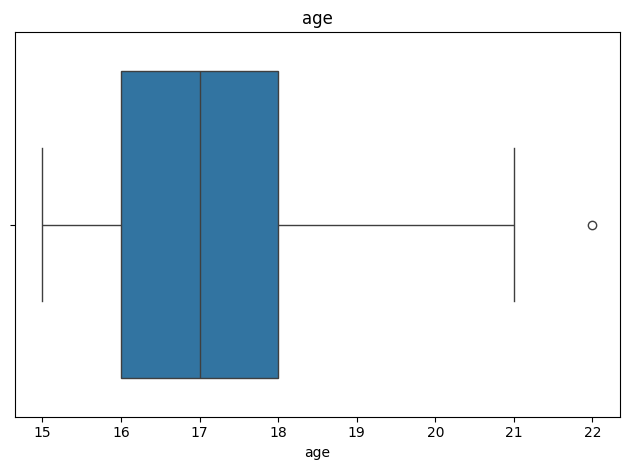

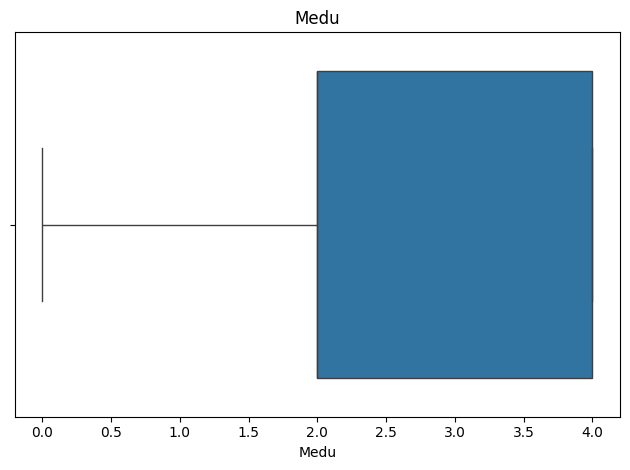

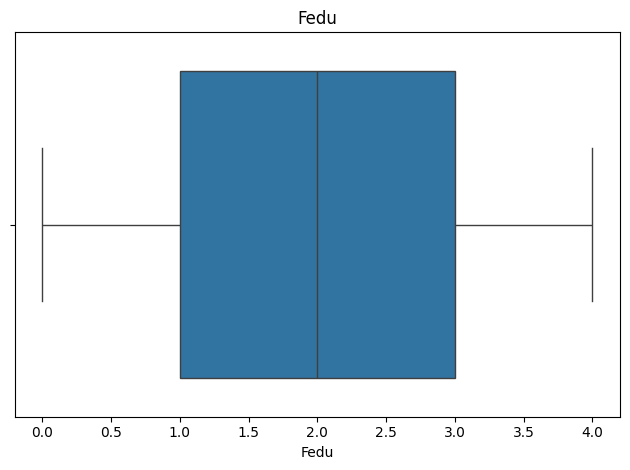

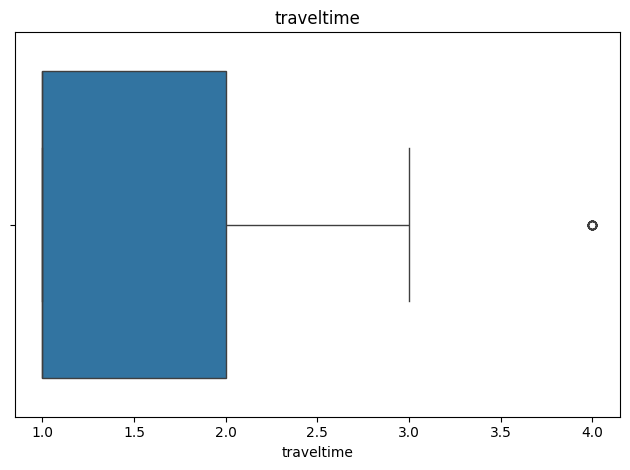

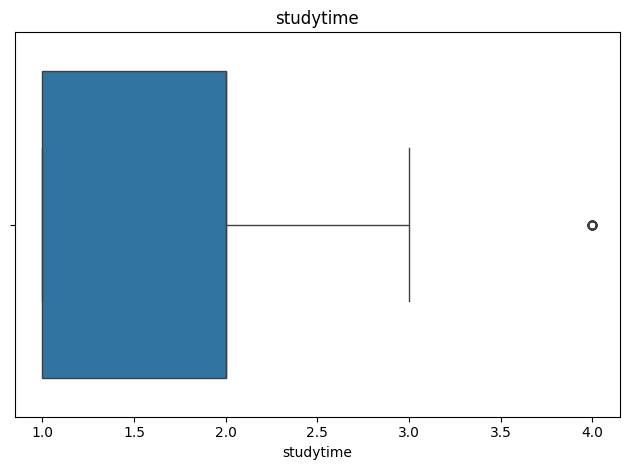

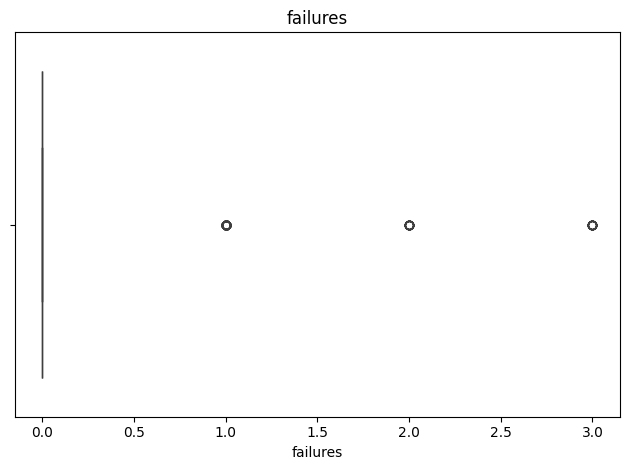

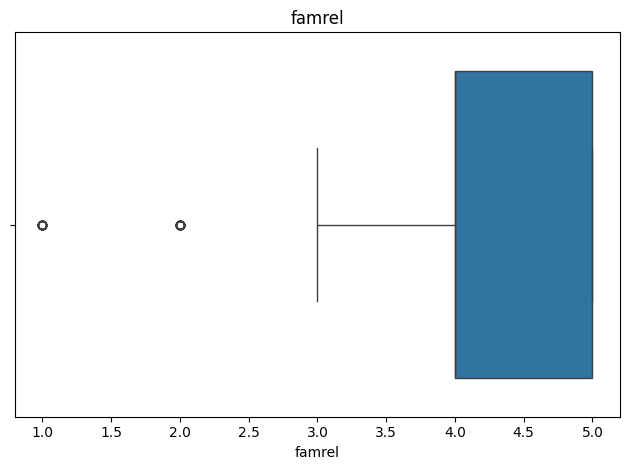

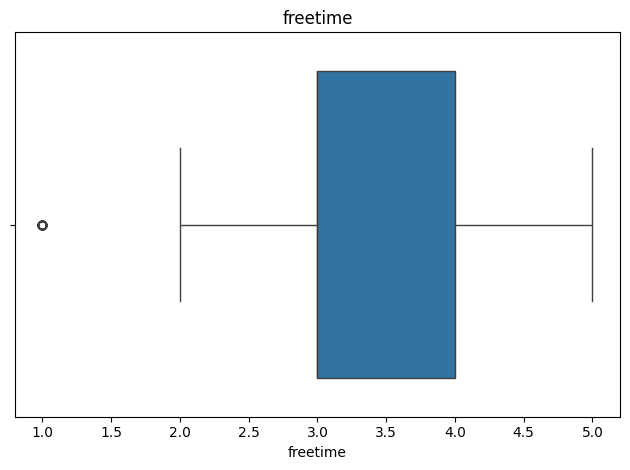

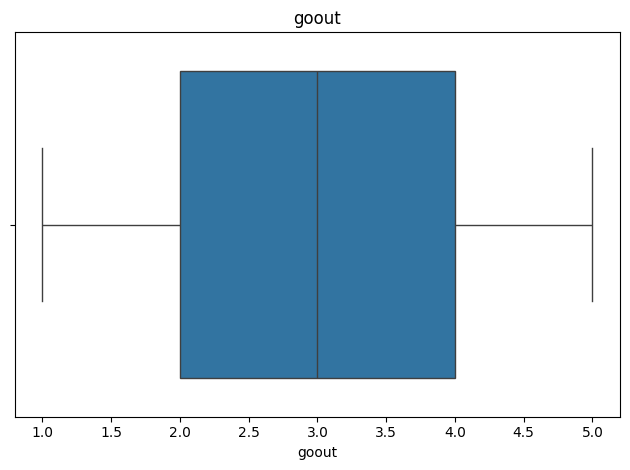

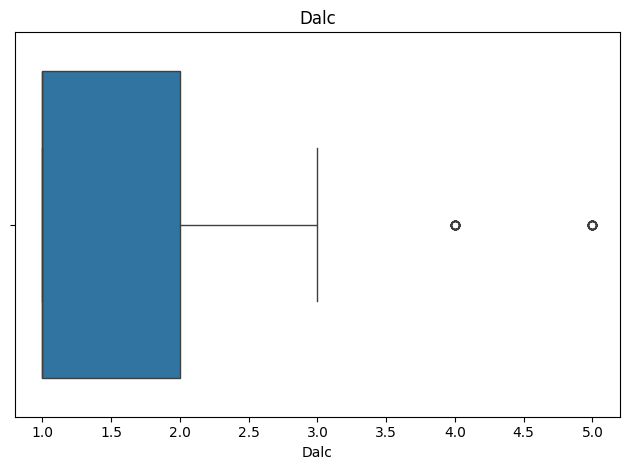

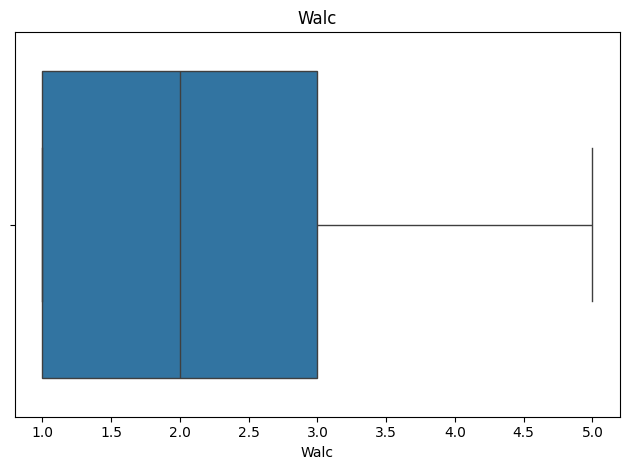

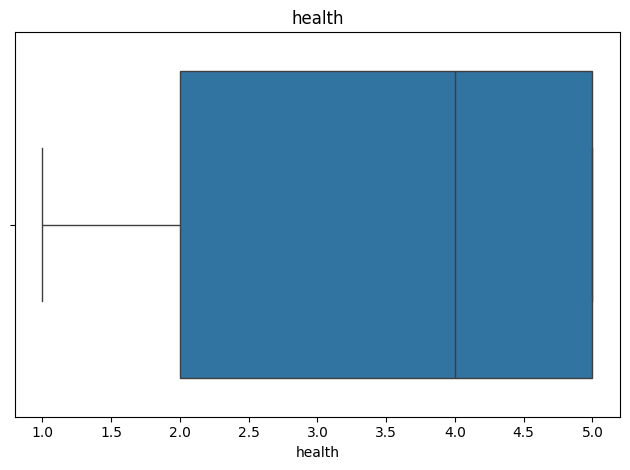

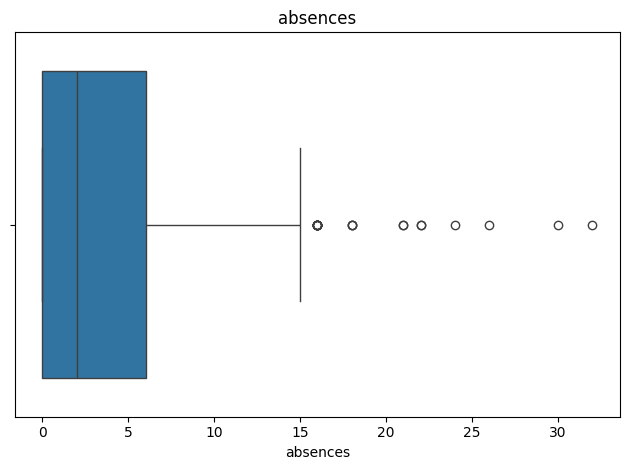

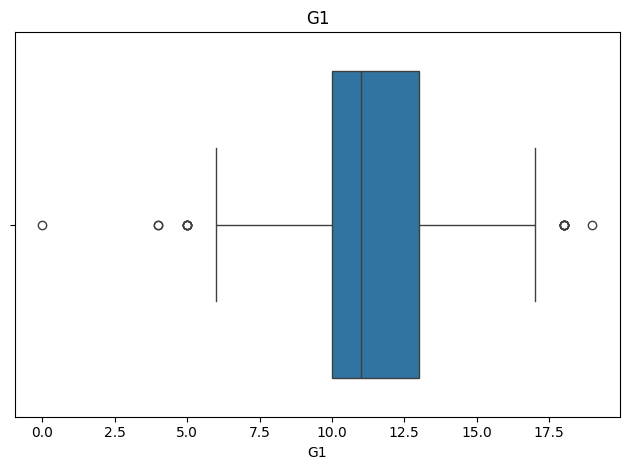

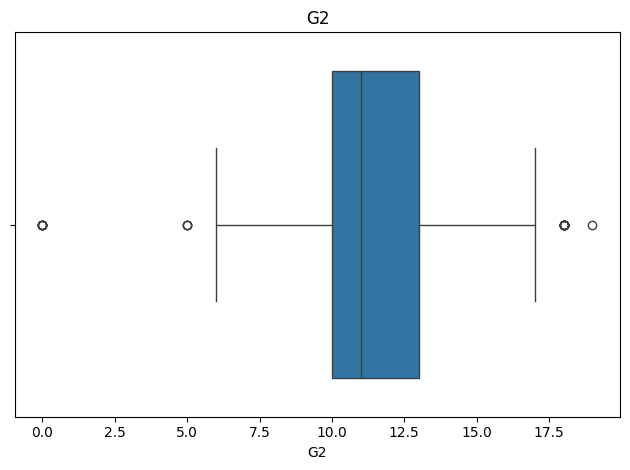

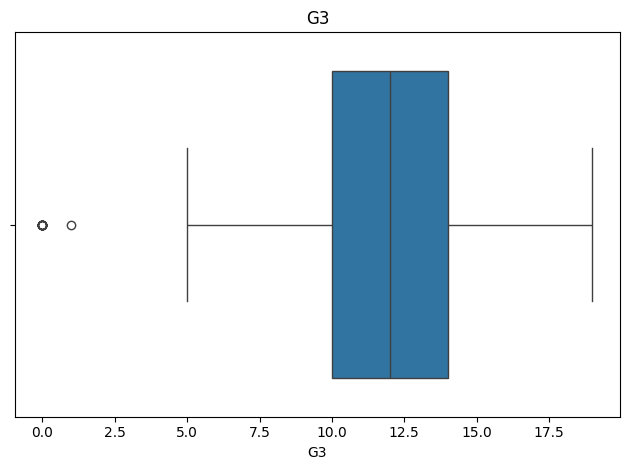

In [43]:
for col in num_cols:
  sns.boxplot(x = df[col])
  plt.title(col)
  plt.tight_layout()
  plt.show()

In [44]:
#الاعمدة الي فيها outliears
#age,traveltime	,studytime	,failures,famrel,freetime,Dalc,absences	G1, G2,G3

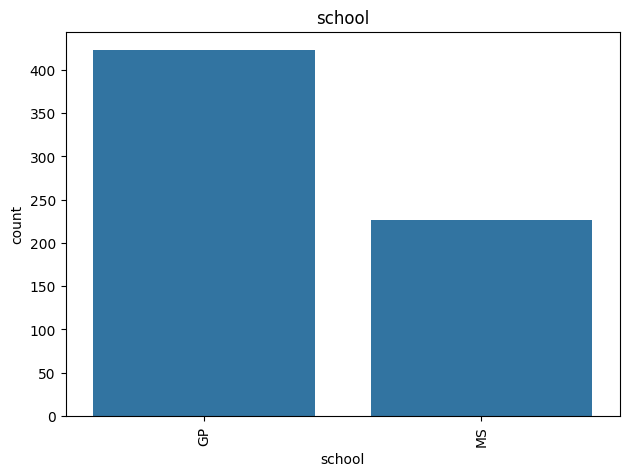

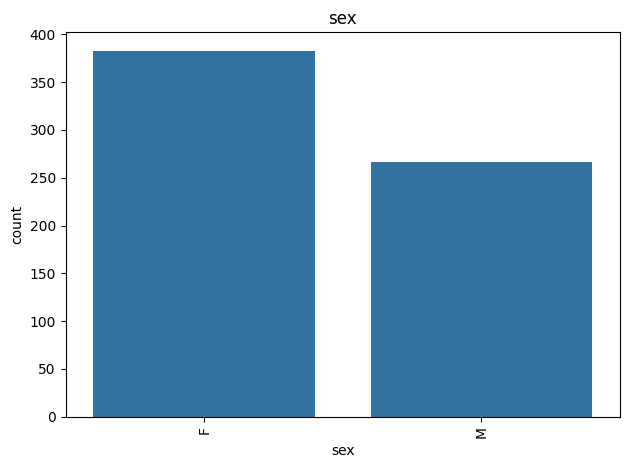

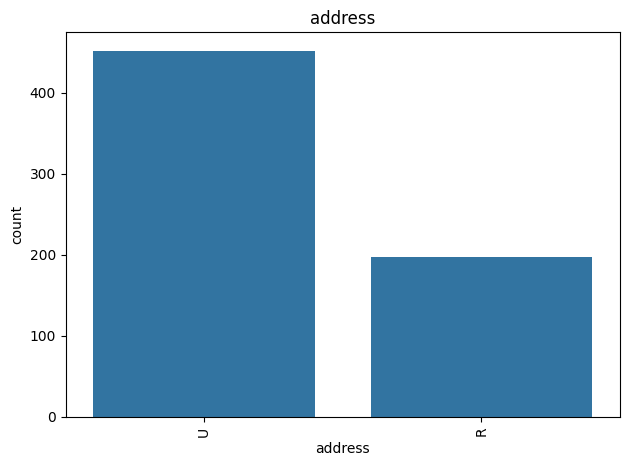

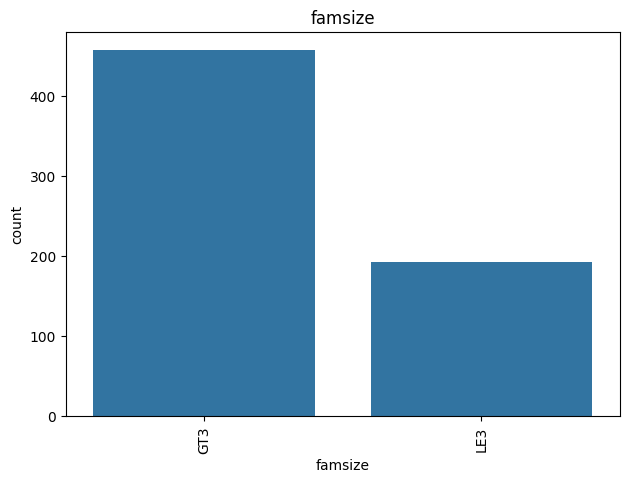

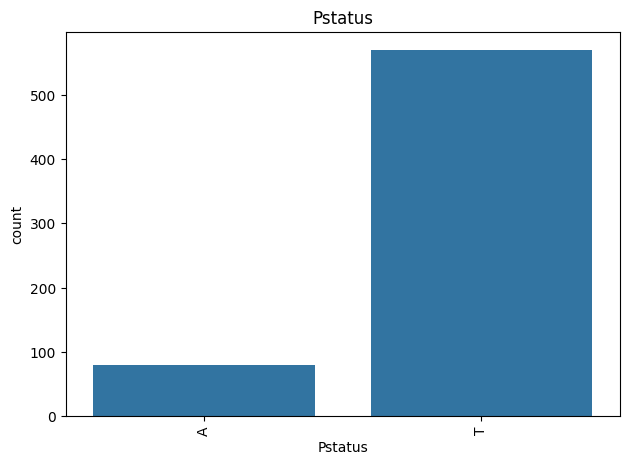

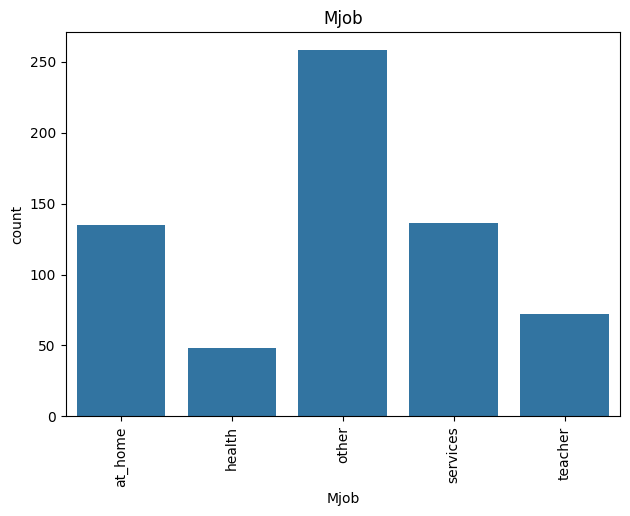

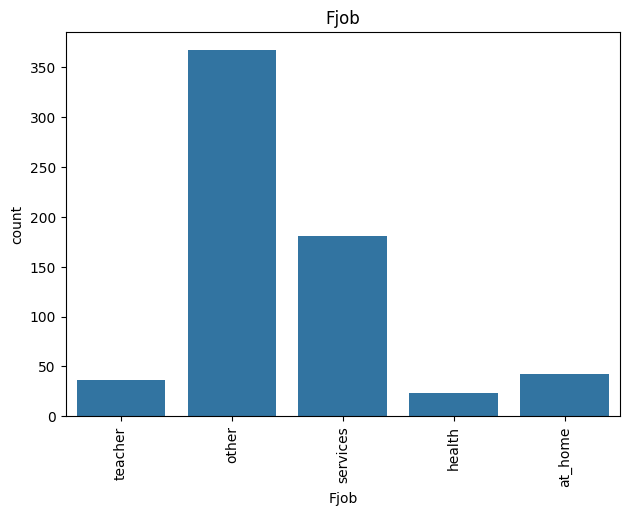

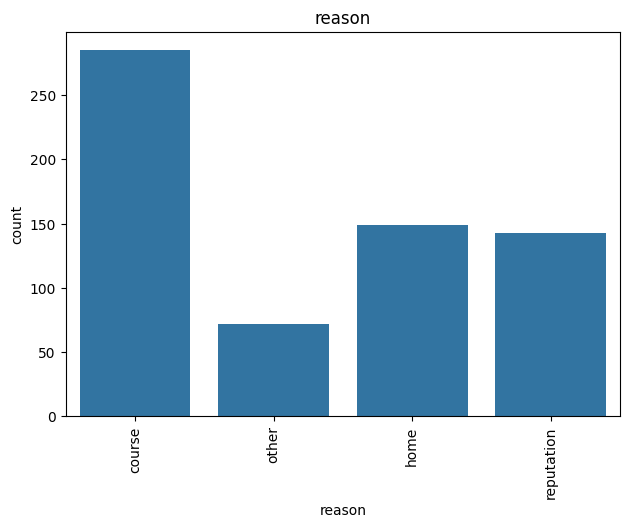

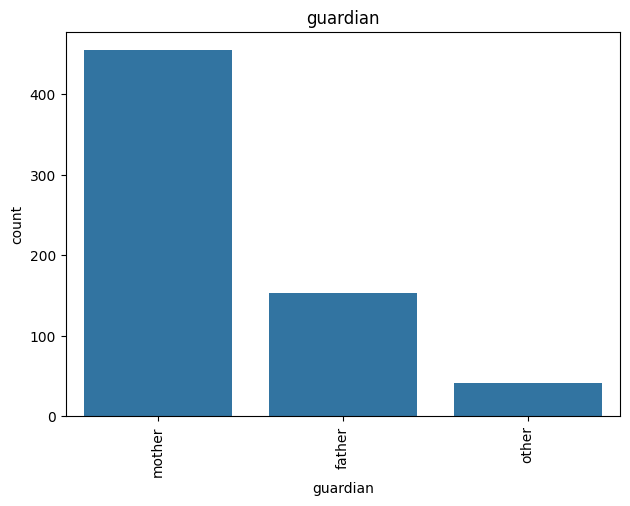

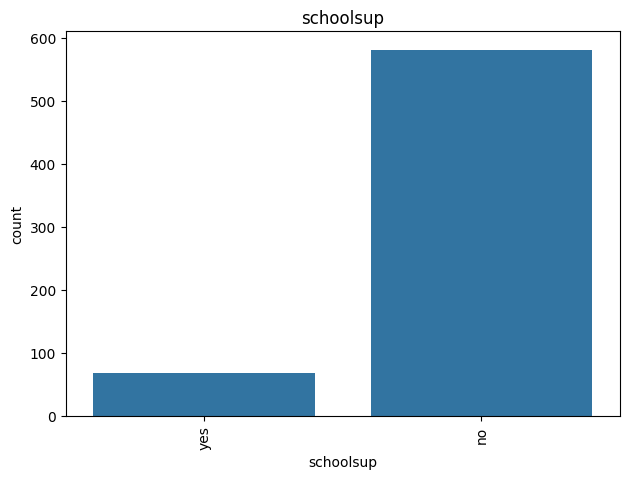

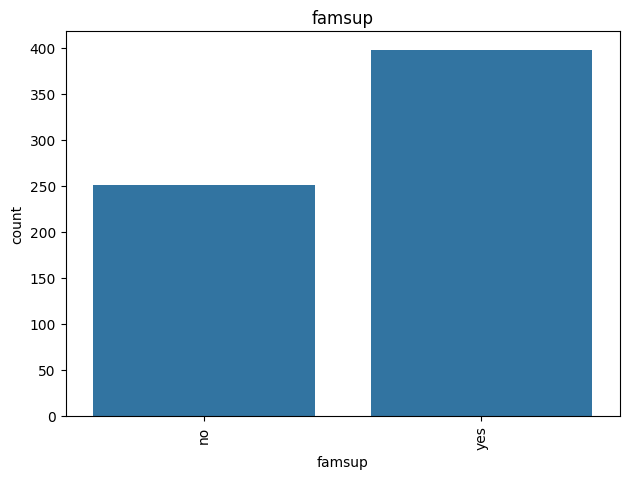

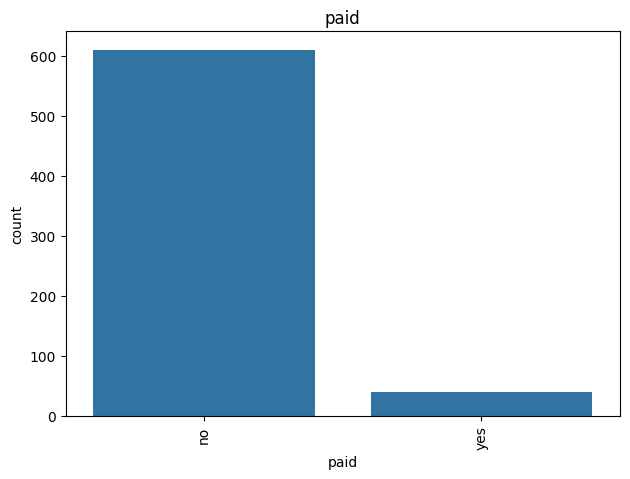

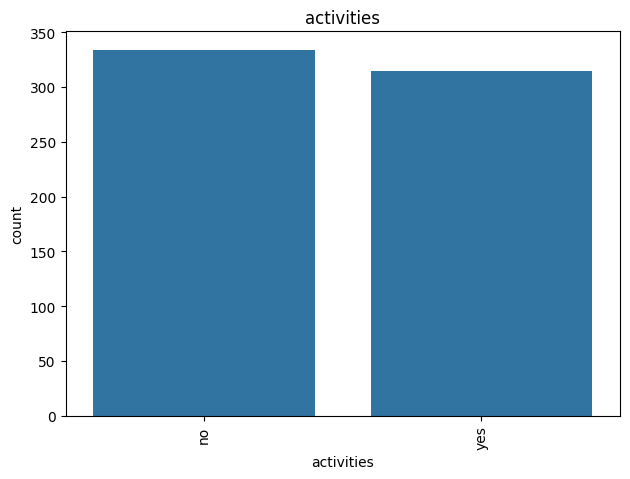

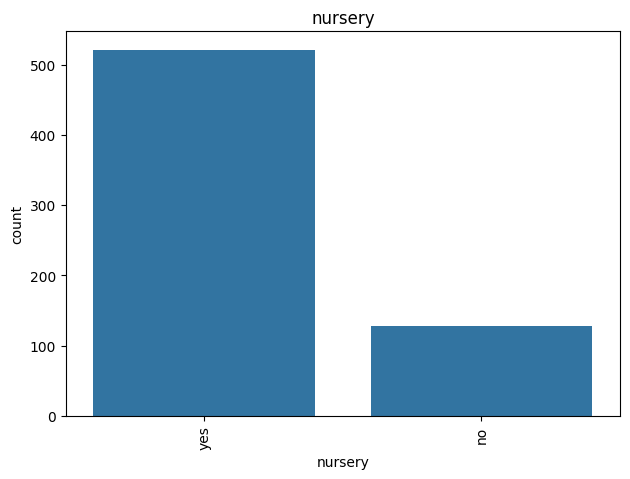

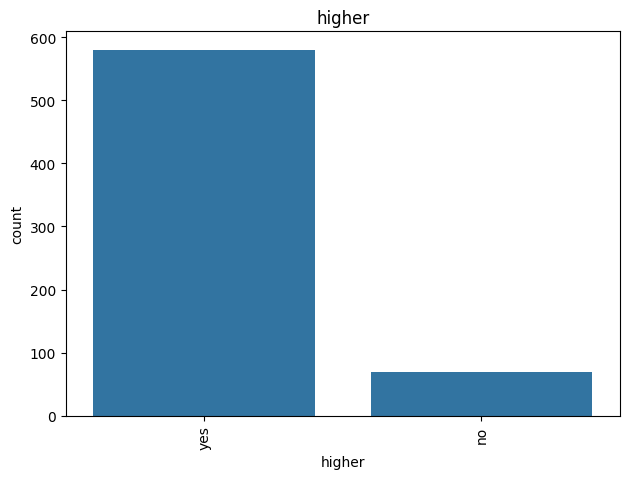

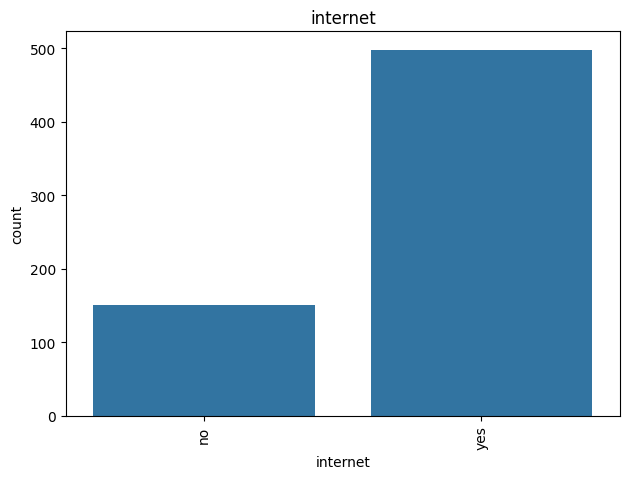

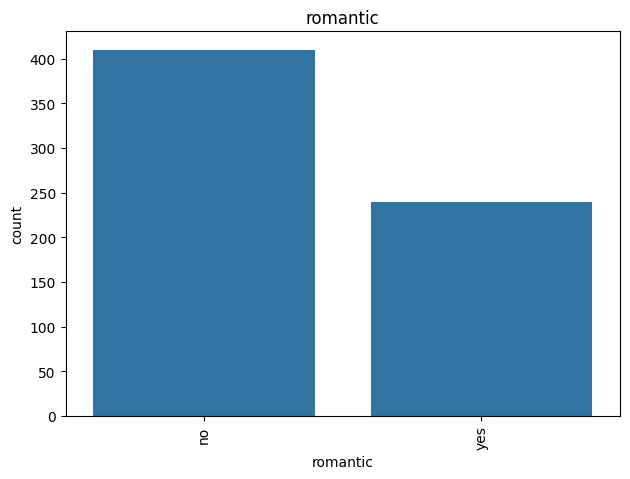

In [45]:
#EDA :Exploratory Data Analysis :التحليل الاستكشافي للبيانات
for col in cat_cols:
  sns.countplot(x = df[col])
  plt.title(col)
  plt.tight_layout()
  plt.xticks(rotation=90)
  plt.show()

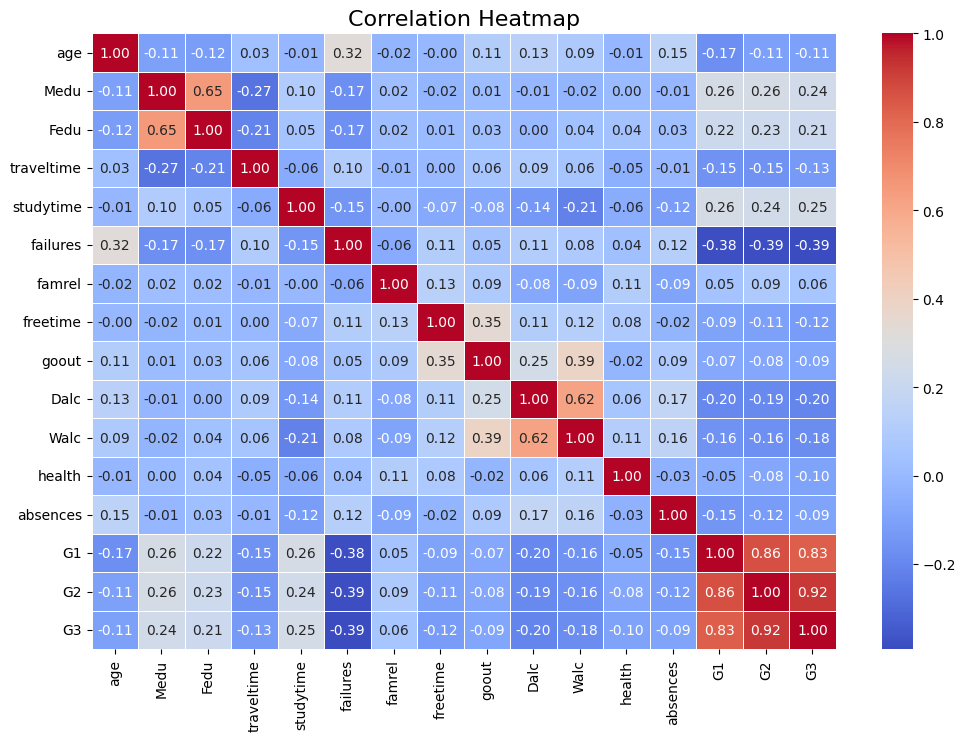

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# حساب مصفوفة الارتباط
corr_matrix = df[num_cols].corr()

# ضبط حجم الشكل
plt.figure(figsize=(12,8))

# رسم الـ heatmap مع تحسينات
sns.heatmap(corr_matrix,
            annot=True,        # إظهار القيم
            cmap="coolwarm",   # اختيار ألوان واضحة
            fmt=".2f",         # تنسيق الأرقام
            linewidths=0.5)    # خطوط فاصلة بين المربعات

plt.title("Correlation Heatmap", fontsize=16)
plt.show()

In [47]:
#libs
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder

In [48]:
# #1-Missng Values
# df.isnull().sum() #لايوجد قيم فارغة يعني فش شغل عليها

In [49]:
#2-Label Encoding إذا كانت ثنائية
#0,1 لها  قيم رقمية باستخدام

In [50]:
df.describe(include=object)

,school,sex,address,famsize,Pstatus,Mjob,Fjob,reason,guardian,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
count,649,649,649,649,649,649,649,649,649,649,649,649,649,649,649,649,649
unique,2,2,2,2,2,5,5,4,3,2,2,2,2,2,2,2,2
top,GP,F,U,GT3,T,other,other,course,mother,no,yes,no,no,yes,yes,yes,no
freq,423,383,452,457,569,258,367,285,455,581,398,610,334,521,580,498,410


In [51]:
#قبل الترميز لازم احول النصوص لقيم
cat_cols=df.dtypes[df.dtypes=='object']

In [52]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

categorical_cols = [
    'school', 'sex', 'address', 'famsize', 'Pstatus',
    'schoolsup', 'famsup', 'paid', 'activities',
    'nursery', 'higher', 'internet', 'romantic'
]

# تطبيق LabelEncoder باستخدام for loop
for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

In [53]:
# df.dtypes #اصبح كلها ارقام ما عدا 4 اعمدة
df.describe(include=object)

,Mjob,Fjob,reason,guardian
count,649,649,649,649
unique,5,5,4,3
top,other,other,course,mother
freq,258,367,285,455


In [54]:
# OneHotEncoder للأعمدة متعددة الفئات
#OHE تحويل احادي
ohe = OneHotEncoder(handle_unknown='ignore')
encoded_df = pd.DataFrame(ohe.fit_transform(df[['Mjob','Fjob','reason','guardian']]).toarray(),columns=ohe.get_feature_names_out())


In [55]:
encoded_df

,Mjob_at_home,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_at_home,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_course,reason_home,reason_other,reason_reputation,guardian_father,guardian_mother,guardian_other
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
645,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
646,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
647,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [56]:
df= df.join(encoded_df) #ضميت اسماء الكولوم الججد في داتا فريم
df.drop(['Fjob','Mjob','guardian','reason'],axis=1,inplace=True) #وحدفت الاسماء القديمة

In [ ]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# # حساب معامل الارتباط مع G3
# corr = new_df.corr()['G3'].sort_values()

# # عرض القيم
# print(corr)

# # رسم Heatmap بسيط
# plt.figure(figsize=(10,8))
# sns.heatmap(new_df.corr()[['G3']].sort_values(by='G3', ascending=False), annot=True, cmap='coolwarm')
# plt.show()

In [57]:
new_df = df.copy()

In [58]:
# قائمة الأعمدة المرشحة للحذف
drop_cols = [
    'Dalc','Walc','school','address','famsize','Pstatus',
    'Mjob_at_home','Mjob_other','Fjob_at_home','Fjob_other','Fjob_services',
    'guardian_other','guardian_father','guardian_mother',
    'reason_other','reason_home','reason_course',
    'romantic','famsup','famrel','freetime','goout','paid','schoolsup','health'
]

# إنشاء نسخة جديدة بدون الأعمدة غير المفيدة
df_reduced = new_df.drop(columns=drop_cols)

print("عدد الأعمدة بعد الحذف:", df_reduced.shape[1])

عدد الأعمدة بعد الحذف: 21


In [59]:
#outliears
num_cols

['age',
 'Medu',
 'Fedu',
 'traveltime',
 'studytime',
 'failures',
 'famrel',
 'freetime',
 'goout',
 'Dalc',
 'Walc',
 'health',
 'absences',
 'G1',
 'G2',
 'G3']

In [60]:
#outliers
def remove_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]

new_df = df.copy()
outliers_cols = ['age','Medu','Fedu','traveltime','studytime',
                'failures','famrel','freetime','goout','Dalc',
                'Walc','health','absences','G1','G2','G3']#هكتب الاسماء الي هشتغل عليها

for col in outliers_cols:
    new_df = remove_outliers(new_df, col)

new_df.shape, df.shape

((396, 46), (649, 46))

In [62]:
from sklearn.model_selection import train_test_split

X = df.drop("G3", axis=1)   # غيري target_column لاسم العمود الذي تتنبئين به
y = df["G3"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [65]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

dt = DecisionTreeRegressor(random_state=42)

param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}

grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("أفضل إعدادات:", grid_search.best_params_)
print("أفضل R² على التدريب:", grid_search.best_score_)

best_dt = grid_search.best_estimator_
print("R² على الاختبار:", best_dt.score(X_test, y_test))

أفضل إعدادات: {'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}
أفضل R² على التدريب: 0.8239161742587277
R² على الاختبار: 0.8232769052108879


In [66]:
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.model_selection import GridSearchCV

# # تعريف النموذج
# dt = DecisionTreeRegressor(random_state=42)

# # تحديد نطاق القيم للتجربة
# param_grid = {
#     'max_depth': [3, 5, 7, 10, None],
#     'min_samples_split': [2, 5, 10, 20],
#     'min_samples_leaf': [1, 2, 5, 10]
# }

# # GridSearchCV
# grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='r2', n_jobs=-1)
# grid_search.fit(X_train_scaled, y_train_scaled)

# # أفضل إعدادات
# print("أفضل إعدادات:", grid_search.best_params_)
# print("أفضل R² على التدريب:", grid_search.best_score_)

# # تقييم على بيانات الاختبار
# best_dt = grid_search.best_estimator_
# print("R² على الاختبار:", best_dt.score(X_test_scaled, y_test_scaled))

In [67]:
#Normalization
scaler = MinMaxScaler()
scaled_df = new_df.copy()
scaled_df[num_cols] = scaler.fit_transform(scaled_df[num_cols])

In [68]:
# df.info()

In [69]:
from sklearn.model_selection import train_test_split

# تقسيم البيانات الأصلية
X = new_df.drop('G3', axis=1)
y = new_df['G3']

# تقسيم البيانات بعد الـ Scaling
X_scaled = scaled_df.drop('G3', axis=1)
y_scaled = scaled_df['G3']

# تقسيم البيانات الأصلية إلى تدريب واختبار
X_train, X_test, y_train, y_test = train_test_split(
    X, y, shuffle=True, test_size=0.2, random_state=42
)

# تقسيم البيانات بعد الـ Scaling إلى تدريب واختبار
X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = train_test_split(
    X_scaled, y_scaled, shuffle=True, test_size=0.2, random_state=42
)
#stratify=y غير مناسب ل رقريش

In [70]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error


In [71]:
# نماذج الريغريشن
LR = LinearRegression()
KNN = KNeighborsRegressor()
DT = DecisionTreeRegressor()
SVM = SVR()
GB = GradientBoostingRegressor()
RF = RandomForestRegressor()




In [72]:
#Noraml DF

LR.fit(X_train, y_train)
KNN.fit(X_train, y_train)
DT.fit(X_train, y_train)
SVM.fit(X_train, y_train)
GB.fit(X_train, y_train)
RF.fit(X_train, y_train)

RandomForestRegressor()

In [73]:
# نماذج الريغريشن مع البيانات بعد الـ Scaling
LR_scaled = LinearRegression()
KNN_scaled = KNeighborsRegressor()
DT_scaled = DecisionTreeRegressor()
SVM_scaled = SVR()
GB_scaled = GradientBoostingRegressor()
RF_scaled = RandomForestRegressor()

In [74]:
LR_scaled.fit(X_train_scaled, y_train_scaled)
KNN_scaled.fit(X_train_scaled, y_train_scaled)
DT_scaled.fit(X_train_scaled, y_train_scaled)
SVM_scaled.fit(X_train_scaled, y_train_scaled)
GB_scaled.fit(X_train_scaled, y_train_scaled)
RF_scaled.fit(X_train_scaled, y_train_scaled)

RandomForestRegressor()

In [75]:
# testing
# Normal
print(LR.score(X_train, y_train))
print(KNN.score(X_train, y_train))
print(DT.score(X_train, y_train))
print(SVM.score(X_train, y_train))
print(GB.score(X_train, y_train))
print(RF.score(X_train, y_train))

0.9124002777179073
0.8866717335863539
1.0
0.8888543570237752
0.9700661616920196
0.9837928133284942


In [76]:
print(LR.score(X_test, y_test))
print(KNN.score(X_test, y_test))
print(DT.score(X_test, y_test))
print(SVM.score(X_test, y_test))
print(GB.score(X_test, y_test))
print(RF.score(X_test, y_test))

0.8939161656466456
0.8248913637428117
0.7439567016210871
0.8994754296914265
0.8876628272912275
0.8812685592360334


In [77]:
print(LR_scaled.score(X_train_scaled, y_train_scaled))
print(KNN_scaled.score(X_train_scaled, y_train_scaled))
print(DT_scaled.score(X_train_scaled, y_train_scaled))
print(SVM_scaled.score(X_train_scaled, y_train_scaled))
print(GB_scaled.score(X_train_scaled, y_train_scaled))
print(RF_scaled.score(X_train_scaled, y_train_scaled))

0.9124002777179073
0.5010593985121484
1.0
0.8691229570309232
0.9700661616920196
0.9833950123933384


In [78]:
print(LR_scaled.score(X_test_scaled, y_test_scaled))
print(KNN_scaled.score(X_test_scaled, y_test_scaled))
print(DT_scaled.score(X_test_scaled, y_test_scaled))
print(SVM_scaled.score(X_test_scaled, y_test_scaled))
print(GB_scaled.score(X_test_scaled, y_test_scaled))
print(RF_scaled.score(X_test_scaled, y_test_scaled))

0.8939161656466458
0.17841326012854197
0.7210585204652495
0.7307546821200948
0.8880840206125062
0.8801725690198017


In [ ]:
#Fine Tuning for the top 3 Models


In [80]:
results = []

def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    results.append([model_name, r2, mae, rmse])

evaluate_model(y_test_scaled, y_GB_hat, "Gradient Boosting")
evaluate_model(y_test_scaled, y_RF_hat, "Random Forest")
evaluate_model(y_test_scaled, y_LR_hat, "Linear Regression")

import pandas as pd
pd.DataFrame(results, columns=["Model","R2","MAE","RMSE"])

,Model,R2,MAE,RMSE
0,Gradient Boosting,0.888084,0.055024,0.068315
1,Random Forest,0.880173,0.057104,0.070688
2,Linear Regression,0.893916,0.052702,0.066511


In [81]:
print("Best model: Linear Regression with highest R2 score.")

Best model: Linear Regression with highest R2 score.


# The Linear Regression model achieved the best performance among the tested models,
# with an R² score of 0.894, MAE of 0.053,and RMSE of 0.067.
# This indicates that it provides the most accurate predictions for student performance in this dataset.